# 

In [3]:
from pathlib import Path
from datetime import datetime, timedelta
import time

import requests
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray as rxr
import matplotlib.pyplot as plt
import cartopy 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob

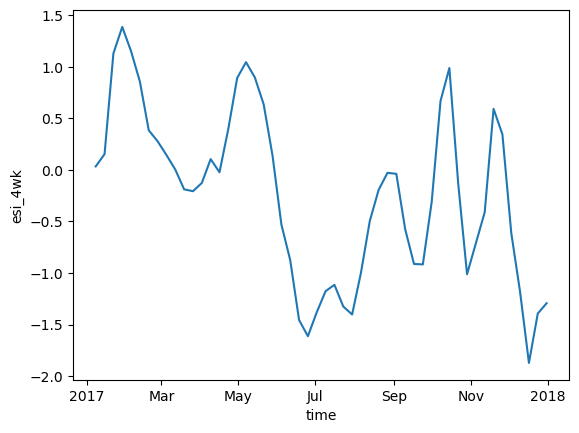

In [4]:
#ESI

esi_4wk = xr.open_dataset('data/raw/esi/2017_4WK/esi_2017_4WK.nc')
esi_4wk.load()
x = (esi_4wk.where(esi_4wk > -9000)).count()
y =(esi_4wk == -9.999e+03).sum()

esi_4wk = esi_4wk.where(esi_4wk > -9000)

esi_regional_mean = esi_4wk["esi_4wk"].mean(dim=("lat", "lon"))
esi_regional_mean.plot()



In [5]:
#EDDI

ds = xr.open_dataset('data/intermediate/eddi_04wk_2017_region.nc')
ds.load()
eddi_04wk = ds['EDDI_04wk']
eddi_04wk = eddi_04wk.sel(time=slice("2017-01-01", "2017-12-31"))
eddi_regional_mean = eddi_04wk.mean(dim=("lat", "lon"))
eddi_regional_mean = eddi_regional_mean.reset_coords("band", drop=True)

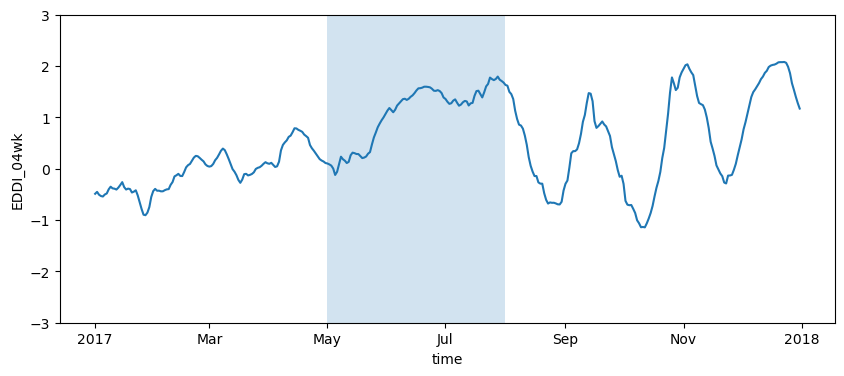

In [6]:
fig, ax = plt.subplots(figsize=(10,4))

eddi_regional_mean.plot(ax=ax)

ax.axvspan("2017-05-01", "2017-08-01", alpha=0.2)
ax.set_ylim(top=3, bottom=-3)
plt.show()

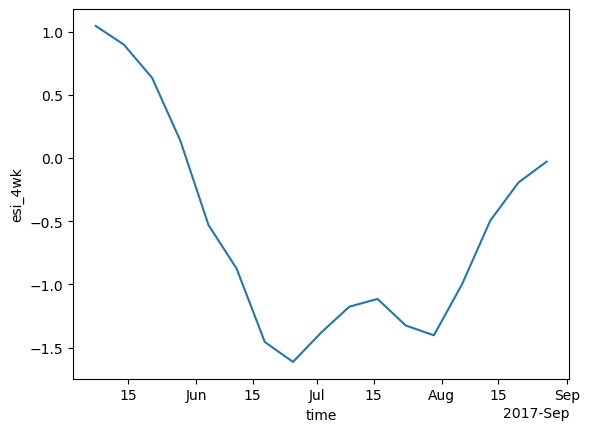

In [11]:
esi_regional_mean_drought = esi_regional_mean.sel(time=slice("2017-05-01", "2017-08-31"))

esi_regional_mean_drought.plot()

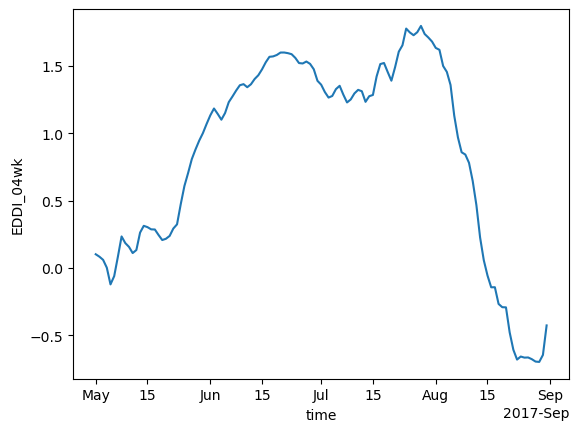

In [10]:
eddi_regional_mean_drought = eddi_regional_mean.sel(time=slice("2017-05-01", "2017-08-31"))

eddi_regional_mean_drought.plot()

In [ ]:
esi_regional_mean = esi_regional_mean.sortby("time")
eddi_regional_mean = eddi_regional_mean.sortby("time")
esi_regional_mean, eddi_regional_mean = xr.align(
    esi_regional_mean, eddi_regional_mean, join="inner"
)

# normalize indices
esi_norm = (esi_regional_mean - esi_regional_mean.mean()) / esi_regional_mean.std()
eddi_norm = (eddi_regional_mean - eddi_regional_mean.mean()) / eddi_regional_mean.std()

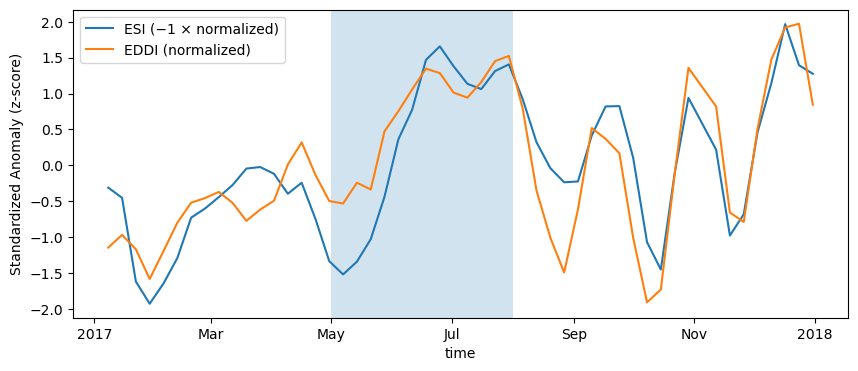

In [44]:
fig, ax = plt.subplots(figsize=(10,4))

esi_norm = -1 * esi_norm

esi_norm.plot(ax=ax, label="ESI (−1 × normalized)")
eddi_norm.plot(ax=ax, label="EDDI (normalized)")

ax.axvspan("2017-05-01", "2017-08-01", alpha=0.2)

ax.set_ylabel("Standardized Anomaly (z-score)")
ax.legend()
plt.show()

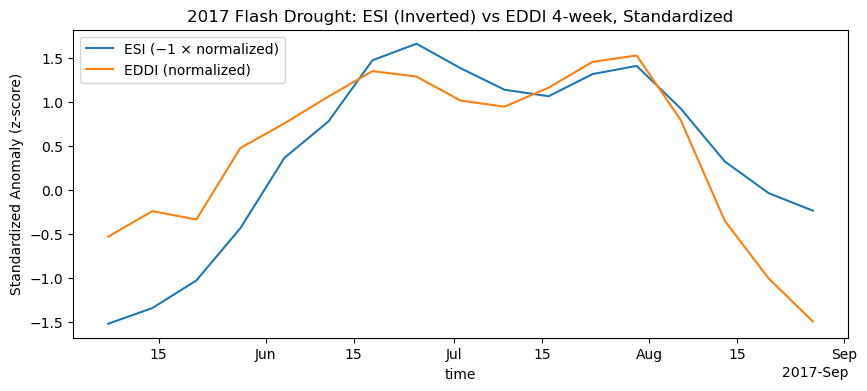

In [60]:
esi_norm_d = esi_norm.sel(time=slice("2017-05-01", "2017-08-31"))
eddi_norm_d = eddi_norm.sel(time=slice("2017-05-01", "2017-08-31"))

fig, ax = plt.subplots(figsize=(10,4))

esi_norm_d.plot(ax=ax, label="ESI (−1 × normalized)")
eddi_norm_d.plot(ax=ax, label="EDDI (normalized)")

ax.set_title(
    "2017 Flash Drought: ESI (Inverted) vs EDDI 4-week, Standardized"
)
ax.set_ylabel("Standardized Anomaly (z-score)")
ax.legend()
plt.show()

In [ ]:
# FDSI

lat_min, lat_max = 45, 49
lon_min, lon_max = -109, -100
year = 2017

ds = xr.open_dataset("FDSI.nc", decode_times=False)

time_vals = ds["Time"].values.astype(str)
time_parsed = pd.to_datetime(time_vals, format="%Y%m%d", errors="coerce")

ds = ds.assign_coords(Time=time_parsed)
fdsi_roll_14 = ds['FDSI'].rolling(Time=14).mean()
fdsi_roll_28 = ds['FDSI'].rolling(Time=28,).mean()

#2017 subset
region_14 = fdsi_roll_14.sel(Time=slice('2017-01-01','2017-12-31'), Latitude=slice(lat_max, lat_min), Longitude = slice(lon_min, lon_max))
region_28 = fdsi_roll_28.sel(Time=slice('2017-01-01','2017-12-31'), Latitude=slice(lat_max, lat_min), Longitude = slice(lon_min, lon_max))



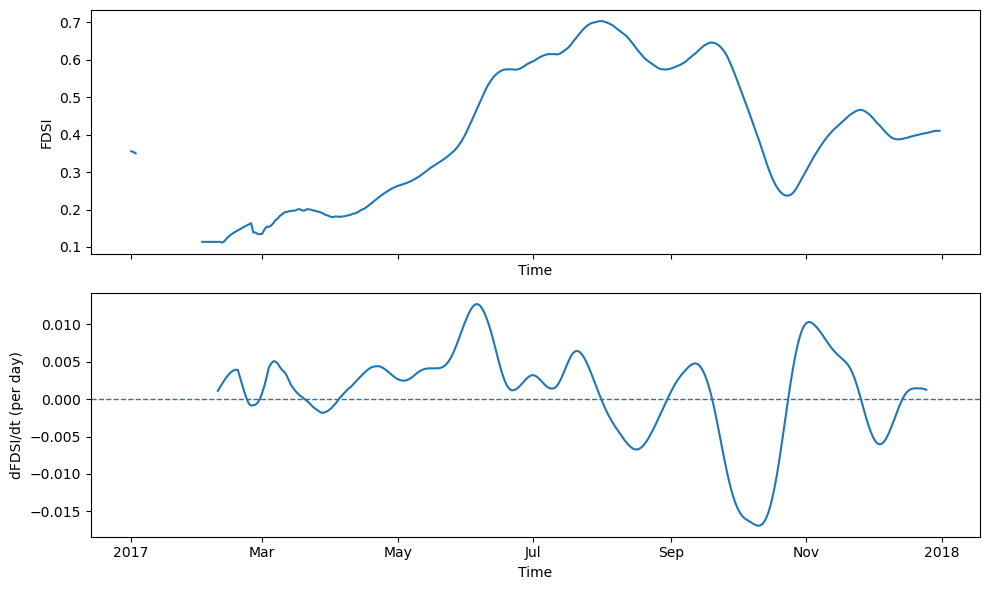

In [ ]:


ts = region_14.mean(dim=["Latitude", "Longitude"], skipna=True)
t = (ts["Time"] - ts["Time"][0]) / np.timedelta64(1, 'D')
t = xr.DataArray(t, coords=[ts["Time"]], dims=["Time"])

def slope(x, y):
    if np.any(np.isnan(y)):
        return np.nan
    coef = np.polyfit(x, y, 1)
    return coef[0] 

rolling_slope_14 = xr.apply_ufunc(
    slope,
    t.rolling(Time=14, center=True).construct("window"),
    ts.rolling(Time=14, center=True).construct("window"),
    input_core_dims=[["window"], ["window"]],
    vectorize=True,
    dask="parallelized",
)

rolling_slope_14 


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,6), sharex=True)

# FDSI
ts.plot(ax=ax1)
ax1.set_ylabel("FDSI")
ax1.set_xlabel("Time")

# rolling slope
rolling_slope_14.plot(ax=ax2)
ax2.axhline(0, linestyle='--', lw=1)
ax2.set_ylabel("dFDSI/dt (per day)")
ax2.set_xlabel("Time")

plt.tight_layout()
plt.show()




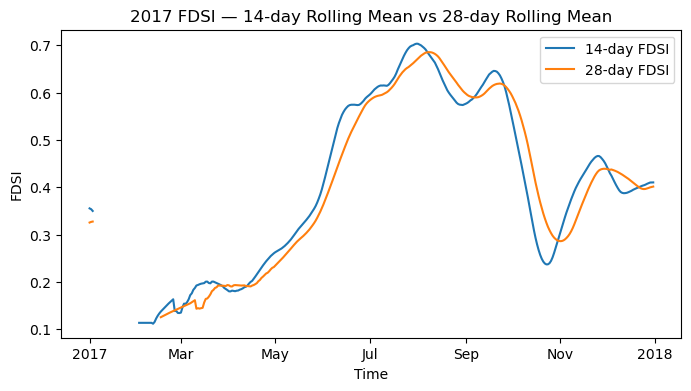

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))

region_14.mean(dim=['Latitude','Longitude']).plot(ax=ax, label='14-day FDSI')
region_28.mean(dim=['Latitude','Longitude']).plot(ax=ax, label='28-day FDSI')
ax.set_title("2017 FDSI — 14-day Rolling Mean vs 28-day Rolling Mean")
ax.set_xlabel("Time")
ax.set_ylabel("FDSI")
ax.legend()

plt.show()


In [26]:
region_28

<xarray.DataArray 'FDSI' (Time: 365, Latitude: 10, Longitude: 23)> Size: 336kB
array([[[0.41712296, 0.2785511 , 0.27044538, ...,        nan,
                nan,        nan],
        [0.29306966, 0.260793  , 0.25625682, ...,        nan,
                nan,        nan],
        [0.34291834, 0.29163575, 0.25919613, ...,        nan,
                nan,        nan],
        ...,
        [0.30410084, 0.28888357, 0.28843117, ...,        nan,
                nan,        nan],
        [0.2738087 ,        nan, 0.25580797, ...,        nan,
                nan,        nan],
        [0.3035601 ,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan, 0.27438006, ...,        nan,
                nan,        nan],
        [0.296876  ,        nan,        nan, ...,        nan,
                nan,        nan],
        [0.34774584,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [0.21979025, 0.23761985, 0.22354761, ..., 0.4465186 ,
                nan, 0.5155153 ],
        [0.19961944,        nan, 0.20045725, ..., 0.685787  ,
         0.6221327 ,        nan],
        [0.25146893,        nan,        nan, ..., 0.40097544,
         0.36916906,        nan]],

       [[0.5361155 , 0.3503153 , 0.36146796, ..., 0.4975177 ,
         0.4728563 , 0.4275107 ],
        [0.29980487, 0.40866682, 0.43475246, ..., 0.36690238,
         0.38034323, 0.38453335],
        [0.45940244, 0.43996835, 0.34145457, ..., 0.34135953,
         0.30994624, 0.33557945],
        ...,
        [0.22189206, 0.24052872, 0.2255068 , ..., 0.44296038,
                nan, 0.5122767 ],
        [0.20022313,        nan, 0.20196454, ..., 0.68198985,
         0.61703885,        nan],
        [0.25237477,        nan,        nan, ..., 0.39843553,
         0.36686793,        nan]]], shape=(365, 10, 23), dtype=float32)
Coordinates:
  * Longitude  (Longitude) float64 184B -108.7 -108.3 -107.9 ... -100.7 -100.3
  * Latitude   (Latitude) float64 80B 48.69 48.31 47.93 ... 46.03 45.65 45.27
  * Time       (Time) datetime64[ns] 3kB 2017-01-01 2017-01-02 ... 2017-12-31
Attributes:
    units:         [-]
    long_name:     Flash drought stress index
    grid_mapping:  crs
    proj4:         +proj=longlat +datum=WGS84 +no_defs
    min:           [3.61057324e-03 9.24923734e-05 1.12919384e-04 ... 2.842011...
    max:           [0.70710582 0.70710623 0.70710653 ... 0.99818605 0.9980533...

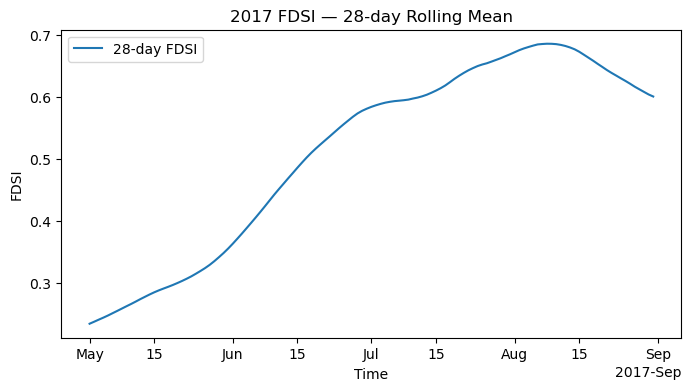

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))
fdsi_regional_mean_drought = region_28.sel(Time=slice("2017-05-01", "2017-08-31"))
fdsi_regional_mean_drought.mean(dim=['Latitude','Longitude']).plot(ax=ax, label='28-day FDSI')
ax.set_title("2017 FDSI — 28-day Rolling Mean")
ax.set_xlabel("Time")
ax.set_ylabel("FDSI")
ax.legend()

plt.show()


In [ ]:
#use 14 day for the mean and comparison 
fdsi_regional_mean = region_14.mean(
    dim=["Latitude", "Longitude"],
    skipna=True
)

fdsi_regional_mean = fdsi_regional_mean.rename({"Time": "time"}) #align w esi/eddi
esi_regional_mean = esi_regional_mean.sortby("time")
eddi_regional_mean = eddi_regional_mean.sortby("time")
fdsi_regional_mean = fdsi_regional_mean.sortby("time")
esi_regional_mean, eddi_regional_mean, fdsi_regional_mean = xr.align(esi_regional_mean, eddi_regional_mean, fdsi_regional_mean, join="inner")

# norm
esi_norm = (esi_regional_mean - esi_regional_mean.mean()) / esi_regional_mean.std()
eddi_norm = (eddi_regional_mean - eddi_regional_mean.mean()) / eddi_regional_mean.std()
fdsi_norm = (fdsi_regional_mean - fdsi_regional_mean.mean()) / fdsi_regional_mean.std()

# invert index
esi_norm_flipped = -1 * esi_norm

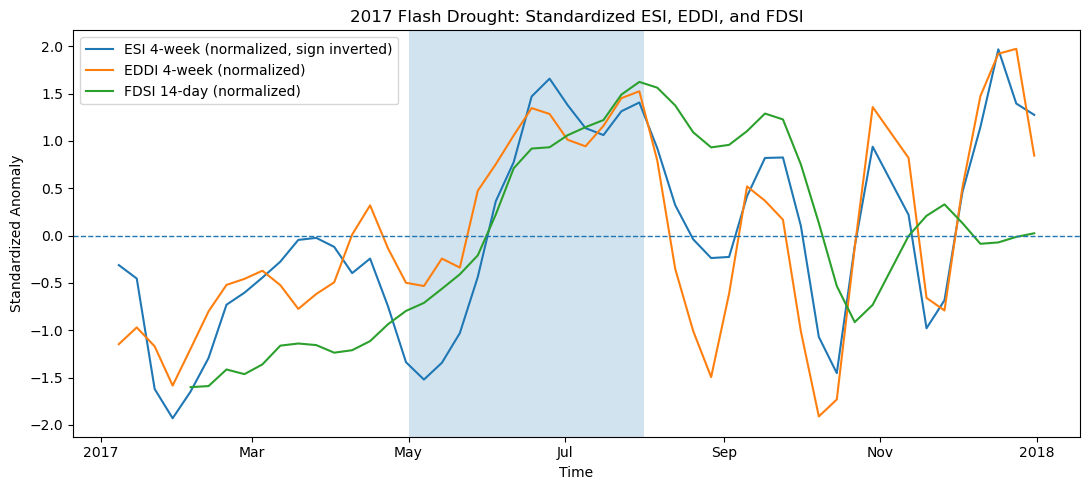

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))

esi_norm_flipped.plot(ax=ax, label="ESI 4-week (normalized, sign inverted)")

eddi_norm.plot(ax=ax, label="EDDI 4-week (normalized)")

fdsi_norm.plot(ax=ax,label="FDSI 14-day (normalized)")

ax.axvspan("2017-05-01", "2017-08-01", alpha=0.2)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_title("2017 Flash Drought: Standardized ESI, EDDI, and FDSI")

ax.set_ylabel("Standardized Anomaly")
ax.set_xlabel("Time")
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

df = pd.DataFrame({"ESI": esi_norm_flipped.values, "EDDI": eddi_norm.values,"FDSI": fdsi_norm.values}, index=esi_norm_flipped["time"].values)

corr_matrix = df.corr()
print(corr_matrix)

df_drought = df.loc["2017-05-01":"2017-08-31"]

corr_matrix_drought = df_drought.corr()
print(corr_matrix_drought)

           ESI      EDDI      FDSI
ESI   1.000000  0.846676  0.613792
EDDI  0.846676  1.000000  0.383809
FDSI  0.613792  0.383809  1.000000
           ESI      EDDI      FDSI
ESI   1.000000  0.775322  0.832883
EDDI  0.775322  1.000000  0.407294
FDSI  0.832883  0.407294  1.000000


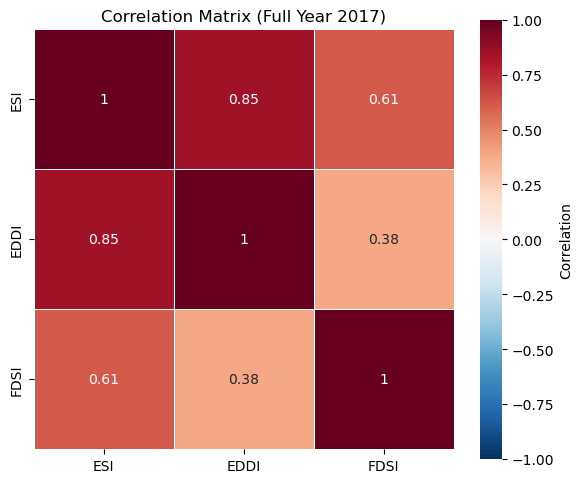

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdBu_r",
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"}
)

plt.title("Correlation Matrix (Full Year 2017)")
plt.tight_layout()
plt.show()

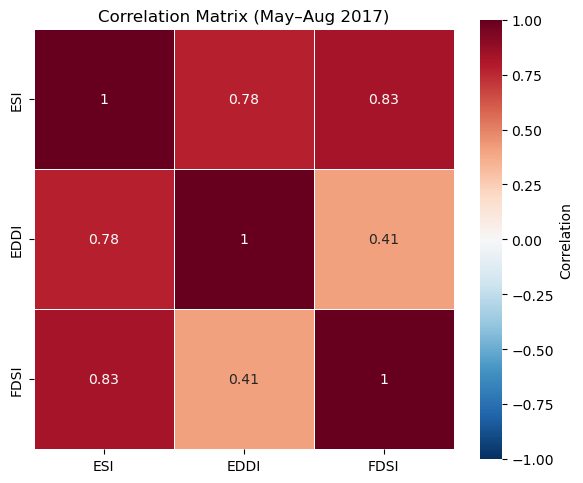

In [43]:
plt.figure(figsize=(6,5))

sns.heatmap(
    corr_matrix_drought,
    annot=True,
    cmap="RdBu_r",
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"}
)

plt.title("Correlation Matrix (May–Aug 2017)")
plt.tight_layout()
plt.show()

In [32]:
import numpy as np

def lag_corr(x, y, max_lag=30):
    lags = np.arange(-max_lag, max_lag+1)
    corrs = []

    for lag in lags:
        if lag < 0:
            corr = np.corrcoef(x[:lag], y[-lag:])[0,1]
        elif lag > 0:
            corr = np.corrcoef(x[lag:], y[:-lag])[0,1]
        else:
            corr = np.corrcoef(x, y)[0,1]
        corrs.append(corr)

    return lags, np.array(corrs)

In [37]:
# EDDI vs ESI
lags, corr_eddi_esi = lag_corr(df["EDDI"].values, df["ESI"].values)

# EDDI vs FDSI
lags, corr_eddi_fdsi = lag_corr(df["EDDI"].values, df["FDSI"].values)

# ESI vs FDSI
lags, corr_esi_fdsi = lag_corr(df["ESI"].values, df["FDSI"].values)

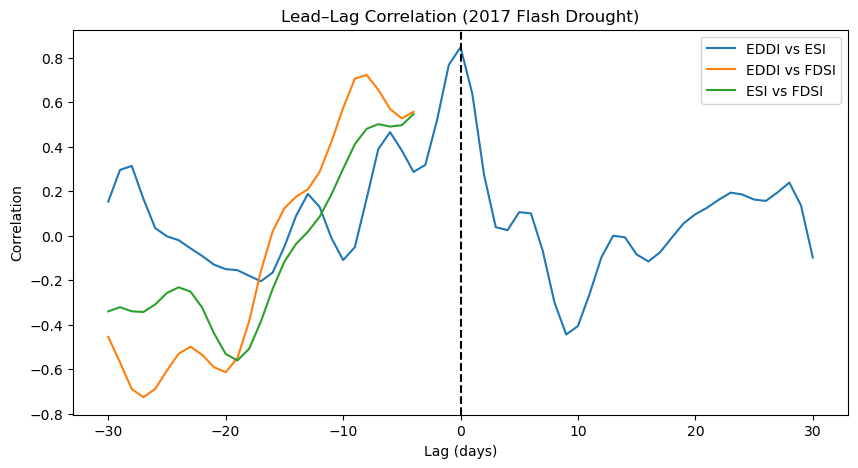

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(lags, corr_eddi_esi, label="EDDI vs ESI")
plt.plot(lags, corr_eddi_fdsi, label="EDDI vs FDSI")
plt.plot(lags, corr_esi_fdsi, label="ESI vs FDSI")

plt.axvline(0, linestyle="--", color="k")
plt.xlabel("Lag (days)")
plt.ylabel("Correlation")
plt.legend()
plt.title("Lead–Lag Correlation (2017 Flash Drought)")
plt.show()

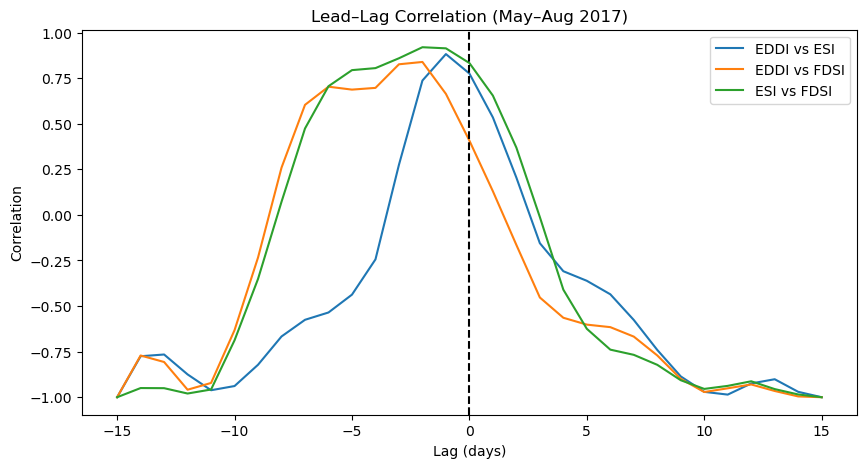

In [39]:
lags, corr_eddi_esi = lag_corr(
    df_drought["EDDI"].values,
    df_drought["ESI"].values
)

lags, corr_eddi_fdsi = lag_corr(
    df_drought["EDDI"].values,
    df_drought["FDSI"].values
)

lags, corr_esi_fdsi = lag_corr(
    df_drought["ESI"].values,
    df_drought["FDSI"].values
)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(lags, corr_eddi_esi, label="EDDI vs ESI")
plt.plot(lags, corr_eddi_fdsi, label="EDDI vs FDSI")
plt.plot(lags, corr_esi_fdsi, label="ESI vs FDSI")

plt.axvline(0, linestyle="--", color="k")
plt.xlabel("Lag (days)")
plt.ylabel("Correlation")
plt.legend()
plt.title("Lead–Lag Correlation (May–Aug 2017)")
plt.show()


In [50]:
event_start = "2017-05-01"
event_peak = "2017-07-31"

metrics = {}

for name, series in {
    "ESI": esi_norm_flipped,
    "EDDI": eddi_norm,
    "FDSI": fdsi_norm
}.items():

    s = series.sel(time=slice(event_start, event_peak))

    start_val = s.sel(time=event_start, method="nearest").item()
    peak_val = s.max().item()
    change = peak_val - start_val

    metrics[name] = {
        "Start value": start_val,
        "Peak value": peak_val,
        "Onset-to-peak change": change
    }

metrics_df = pd.DataFrame(metrics).T
print(metrics_df)

      Start value  Peak value  Onset-to-peak change
ESI     -1.520899    1.657326              3.178224
EDDI    -0.532876    1.523792              2.056668
FDSI    -0.711302    1.622892              2.334194


In [51]:
event_start = pd.Timestamp("2017-05-01")
event_peak = pd.Timestamp("2017-07-31")
days = (event_peak - event_start).days

metrics_df["Rate per day"] = metrics_df["Onset-to-peak change"] / days
metrics_df["Rate per week"] = metrics_df["Rate per day"] * 7

print(metrics_df)

      Start value  Peak value  Onset-to-peak change  Rate per day  \
ESI     -1.520899    1.657326              3.178224      0.034926   
EDDI    -0.532876    1.523792              2.056668      0.022601   
FDSI    -0.711302    1.622892              2.334194      0.025650   

      Rate per week  
ESI        0.244479  
EDDI       0.158205  
FDSI       0.179553  


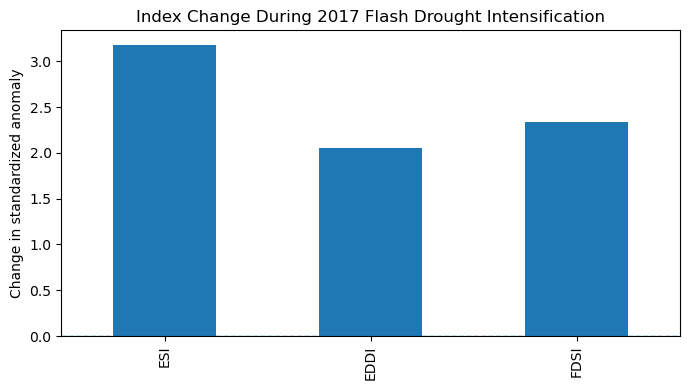

In [52]:
fig, ax = plt.subplots(figsize=(7,4))

metrics_df["Onset-to-peak change"].plot(kind="bar", ax=ax)

ax.set_ylabel("Change in standardized anomaly")
ax.set_title("Index Change During 2017 Flash Drought Intensification")
ax.axhline(0, linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

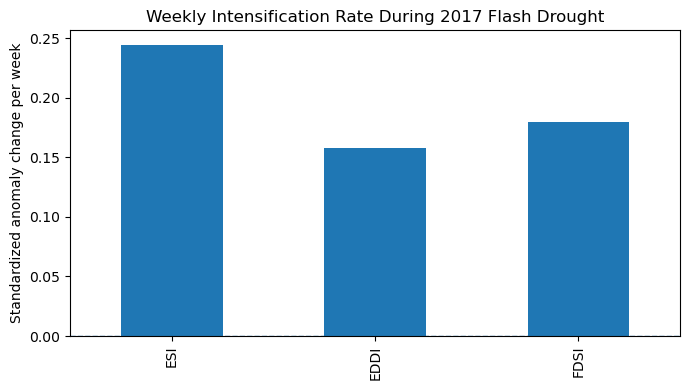

In [53]:
fig, ax = plt.subplots(figsize=(7,4))

metrics_df["Rate per week"].plot(kind="bar", ax=ax)

ax.set_ylabel("Standardized anomaly change per week")
ax.set_title("Weekly Intensification Rate During 2017 Flash Drought")
ax.axhline(0, linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

In [55]:
results = {}

for name, series in {
    "ESI": esi_norm_flipped,
    "EDDI": eddi_norm,
    "FDSI": fdsi_norm
}.items():

    s = series.sel(time=slice("2017-05-01","2017-08-31"))

    peak_val = s.max().item()
    peak_time = s.idxmax().values

    results[name] = {
        "Peak value": peak_val,
        "Peak date": peak_time
    }

results_df = pd.DataFrame(results).T
print(results_df)

     Peak value                      Peak date
ESI    1.657326  2017-06-25T00:00:00.000000000
EDDI   1.523792  2017-07-30T00:00:00.000000000
FDSI   1.622892  2017-07-30T00:00:00.000000000


In [56]:
from scipy.stats import linregress

slopes = {}

for name, series in {
    "ESI": esi_norm_flipped,
    "EDDI": eddi_norm,
    "FDSI": fdsi_norm
}.items():

    s = series.sel(time=slice("2017-05-01","2017-07-15"))

    t = (s["time"] - s["time"][0]) / np.timedelta64(1, 'D')

    slope = linregress(t, s.values).slope
    slopes[name] = slope

print(slopes)

{'ESI': np.float64(0.054141102657550344), 'EDDI': np.float64(0.028660390908565387), 'FDSI': np.float64(0.03345244123240468)}


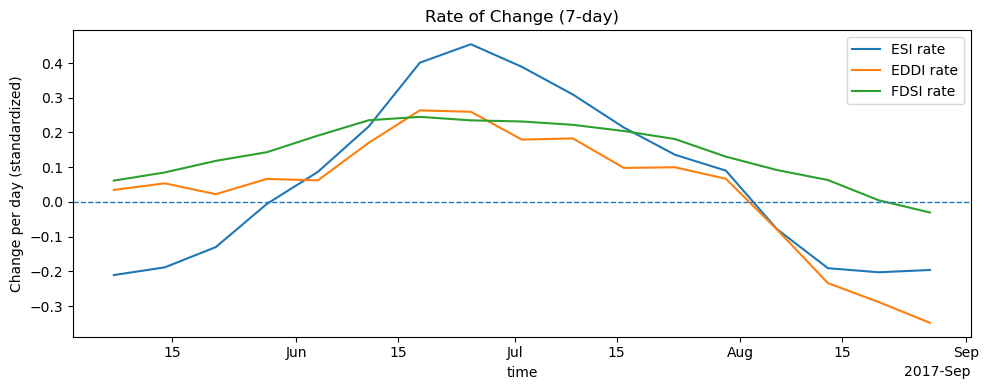

In [58]:
window = 7  # 7-day rate (clean and interpretable)

esi_rate = esi_norm_flipped.diff("time").rolling(time=window).mean()
eddi_rate = eddi_norm.diff("time").rolling(time=window).mean()
fdsi_rate = fdsi_norm.diff("time").rolling(time=window).mean()

# subset to drought period
esi_r = esi_rate.sel(time=slice("2017-05-01","2017-08-31"))
eddi_r = eddi_rate.sel(time=slice("2017-05-01","2017-08-31"))
fdsi_r = fdsi_rate.sel(time=slice("2017-05-01","2017-08-31"))

fig, ax = plt.subplots(figsize=(10,4))

esi_r.plot(ax=ax, label="ESI rate")
eddi_r.plot(ax=ax, label="EDDI rate")
fdsi_r.plot(ax=ax, label="FDSI rate")

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_title("Rate of Change (7-day)")
ax.set_ylabel("Change per day (standardized)")
ax.legend()

plt.tight_layout()
plt.show()